In [2]:
from google.colab import files
uploaded = files.upload()


Saving xy_data.csv to xy_data.csv


            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340


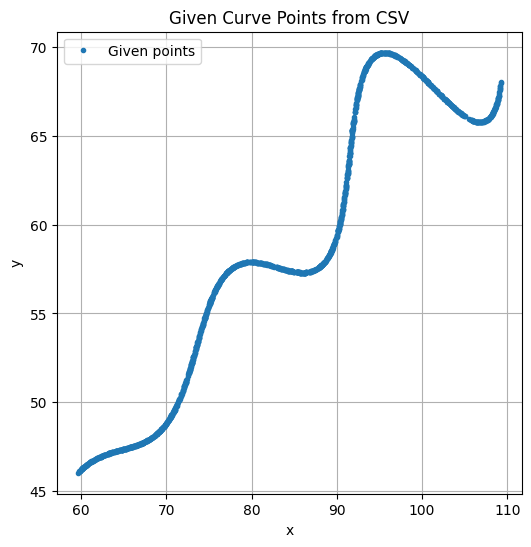

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('xy_data.csv')
print(data.head())

x_real = data['x'].values
y_real = data['y'].values

plt.figure(figsize=(6,6))
plt.plot(x_real, y_real, 'o', markersize=3, label='Given points')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Given Curve Points from CSV')
plt.legend(); plt.grid(True)
plt.show()

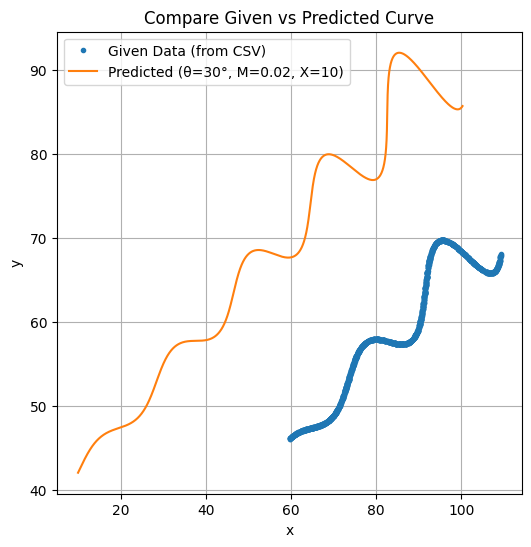

Total L1 error = 75175.46383462212


In [9]:
theta_deg = 30
theta = np.deg2rad(theta_deg)
M = 0.02
X = 10


t = np.linspace(0, 100, len(x_real))

x_pred = t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
y_pred = 42 + t*np.sin(theta) + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)

plt.figure(figsize=(6,6))
plt.plot(x_real, y_real, 'o', markersize=3, label='Given Data (from CSV)')
plt.plot(x_pred, y_pred, '-', label=f'Predicted (θ={theta_deg}°, M={M}, X={X})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.title('Compare Given vs Predicted Curve')
plt.show()

error = np.sum(np.abs(x_pred - x_real) + np.abs(y_pred - y_real))
print("Total L1 error =", error)

In [7]:

best_error = float('inf')
best_theta = None
best_M = None
best_X = None

theta_range = np.deg2rad(np.linspace(5, 50, 10))
M_range = np.linspace(-0.05, 0.05, 11)
X_range = np.linspace(0, 100, 21)

for theta in theta_range:
    for M in M_range:
        for X in X_range:
            x_pred = t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
            y_pred = 42 + t*np.sin(theta) + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)

            error = np.sum(np.abs(x_pred - x_real) + np.abs(y_pred - y_real))

            if error < best_error:
                best_error = error
                best_theta, best_M, best_X = theta, M, X

print(f" Best fit found:")
print(f"θ = {np.rad2deg(best_theta):.3f} degrees")
print(f"M = {best_M:.5f}")
print(f"X = {best_X:.3f}")
print(f"L1 error = {best_error:.3f}")


 Best fit found:
θ = 15.000 degrees
M = -0.05000
X = 35.000
L1 error = 54242.219


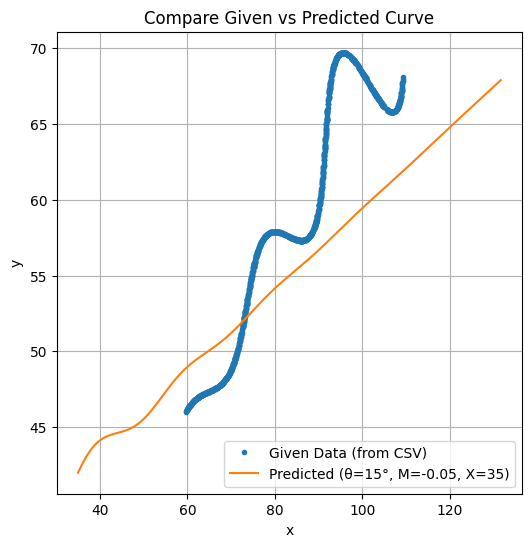

Total L1 error = 54242.219170320655


In [8]:
theta_deg = 15
theta = np.deg2rad(theta_deg)
M = -0.05
X = 35

t = np.linspace(0, 100, len(x_real))

x_pred = t*np.cos(theta) - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta) + X
y_pred = 42 + t*np.sin(theta) + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)

plt.figure(figsize=(6,6))
plt.plot(x_real, y_real, 'o', markersize=3, label='Given Data (from CSV)')
plt.plot(x_pred, y_pred, '-', label=f'Predicted (θ={theta_deg}°, M={M}, X={X})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.title('Compare Given vs Predicted Curve')
plt.show()

error = np.sum(np.abs(x_pred - x_real) + np.abs(y_pred - y_real))
print("Total L1 error =", error)